## §1 Setup & Imports

This notebook trains and compares six ensemble methods from class
(Bagging/RF, AdaBoost, GradientBoosting, XGBoost, Voting, Stacking)
plus a Decision Tree baseline. Hyperparameters are optimised with Optuna
(MedianPruner, 50 trials, macro F1 on val set). The test set is used
only once per model for final evaluation in §12.
Hardware: Ryzen 9800X3D (n_jobs=-1) for sklearn models,
RTX 5070 Ti (device='cuda') for XGBoost.

In [1]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import xgboost as xgb
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, precision_score,
    recall_score, matthews_corrcoef, classification_report,
    ConfusionMatrixDisplay)
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED          = 42
N_TRIALS      = 50
PROCESSED_DIR = '../data/processed/'
CLASS_NAMES   = ['Benign','BruteForce','DDoS','DoS','Mirai','Recon','Spoofing','Web-based']

def load_split(name):
    df = pd.read_parquet(PROCESSED_DIR + name)
    return df.drop(columns='y').values, df['y'].values

X_train, y_train = load_split('train.parquet')
X_val,   y_val   = load_split('val.parquet')
X_test,  y_test  = load_split('test.parquet')

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

results_val  = []
results_test = []

# Checkpoint: si existe, carga params de RF y AdaBoost ya optimizados
_ckpt = PROCESSED_DIR + 'checkpoint_after_ada.json'
if os.path.exists(_ckpt):
    _data           = json.load(open(_ckpt))
    rf_best_params  = _data['rf_best_params']
    ada_best_params = _data['ada_best_params']
    ada_base_depth  = _data['ada_base_depth']
    results_val     = _data['results_val_partial']
    print()
    print('CHECKPOINT CARGADO — salta las celdas §4, §5, §6 y ejecuta desde §7')
    print(f'  rf_best_params : {rf_best_params}')
    print(f'  ada_best_params: {ada_best_params}')
    print(f'  ada_base_depth : {ada_base_depth}')
    print(f'  results_val    : {[r["Model"] for r in results_val]}')

Train: (699626, 39) | Val: (149920, 39) | Test: (149920, 39)

CHECKPOINT CARGADO — salta las celdas §4, §5, §6 y ejecuta desde §7
  rf_best_params : {'n_estimators': 50, 'max_depth': 25, 'min_samples_split': 2, 'max_features': 'sqrt'}
  ada_best_params: {'n_estimators': 250, 'learning_rate': 0.2725843888825499}
  ada_base_depth : 5
  results_val    : ['Decision Tree', 'Random Forest', 'AdaBoost']


## §2 Resampling & Speed Subsamples

RandomOverSampler was selected in notebook 02 as the best imbalance strategy
(macro F1: 0.8247 with a DecisionTree probe). It duplicates minority samples
until all classes reach the majority count — no synthetic interpolation.

Two speed subsamples are derived from X_train_res:
- **X_opt (100K)**: used inside every Optuna objective. Hyperparameter search
  does not require the full dataset; a representative stratified subsample
  is sufficient. The final model always retrains on the larger set.
- **X_final_gbm (500K)**: used only for GradientBoostingClassifier's final model.
  Unlike RF and XGBoost, sklearn GBM is sequential (no tree-level parallelism),
  so training on 4.2M rows is impractical. 500K preserves class balance and
  provides sufficient signal for convergence. All other final models use the
  full 4.2M-row X_train_res.

In [2]:
ros = RandomOverSampler(random_state=SEED)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

_, X_opt, _, y_opt = train_test_split(
    X_train_res, y_train_res,
    test_size=100_000, stratify=y_train_res, random_state=SEED
)

_, X_final_gbm, _, y_final_gbm = train_test_split(
    X_train_res, y_train_res,
    test_size=500_000, stratify=y_train_res, random_state=SEED
)

print(f'Full resampled  : {X_train_res.shape[0]:>10,} rows')
print(f'Optuna subsample: {X_opt.shape[0]:>10,} rows  (HPT trials, all models)')
print(f'GBM subsample   : {X_final_gbm.shape[0]:>10,} rows  (GBM final model only)')
print()

print(f'  {"Class":<15} {"Before":>10} {"After":>10}')
print('  ' + '-'*38)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<15} {int((y_train==i).sum()):>10,} {int((y_train_res==i).sum()):>10,}')

Full resampled  :  4,234,192 rows
Optuna subsample:    100,000 rows  (HPT trials, all models)
GBM subsample   :    500,000 rows  (GBM final model only)

  Class               Before      After
  --------------------------------------
  Benign              17,035    529,274
  BruteForce             118    529,274
  DDoS               529,274    529,274
  DoS                125,990    529,274
  Mirai               13,841    529,274
  Recon                5,442    529,274
  Spoofing             7,571    529,274
  Web-based              355    529,274


## §3 Helper: evaluate_model()

Centralising metric collection ensures consistent reporting across all models.
MCC (Matthews Correlation Coefficient) is included alongside macro F1 as a
secondary metric robust to class imbalance — it accounts for all four cells
of the confusion matrix and is informative when class sizes differ by orders
of magnitude.

In [3]:
def evaluate_model(name, model, X_eval, y_eval, results):
    y_pred = model.predict(X_eval)
    row = {
        'Model':    name,
        'Accuracy': round(accuracy_score(y_eval, y_pred), 4),
        'Macro F1': round(f1_score(y_eval, y_pred, average='macro', zero_division=0), 4),
        'Macro P':  round(precision_score(y_eval, y_pred, average='macro', zero_division=0), 4),
        'Macro R':  round(recall_score(y_eval, y_pred, average='macro', zero_division=0), 4),
        'MCC':      round(matthews_corrcoef(y_eval, y_pred), 4),
    }
    results.append(row)
    for k, v in row.items():
        if k != 'Model':
            print(f'  {k:<12}: {v:.4f}')
    return row

## §4 Baseline — Decision Tree

The Decision Tree baseline reproduces the best result from notebook 02
(RandomOverSampler + DT probe, macro F1 ~0.82) as a reference.
Every ensemble method should exceed this — that is precisely the purpose
of ensembling: combining weak learners to produce a stronger one.
No Optuna tuning is applied to the baseline.

In [10]:
dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train_res, y_train_res)
print('Decision Tree (val):')
evaluate_model('Decision Tree', dt, X_val, y_val, results_val)
print()
print(classification_report(y_val, dt.predict(X_val),
      target_names=CLASS_NAMES, zero_division=0))

Decision Tree (val):
  Accuracy    : 0.9936
  Macro F1    : 0.8247
  Macro P     : 0.8233
  Macro R     : 0.8263
  MCC         : 0.9839

              precision    recall  f1-score   support

      Benign       0.91      0.91      0.91      3650
  BruteForce       0.54      0.54      0.54        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      1.00      1.00      2966
       Recon       0.80      0.79      0.79      1166
    Spoofing       0.83      0.82      0.83      1623
   Web-based       0.51      0.55      0.53        76

    accuracy                           0.99    149920
   macro avg       0.82      0.83      0.82    149920
weighted avg       0.99      0.99      0.99    149920



## §5 Random Forest (Bagging)

Random Forest is the canonical Bagging ensemble (class notebook 2_1).
Each tree is trained on a bootstrap sample; predictions are aggregated
by majority vote. n_jobs=-1 parallelises tree construction across all
16 cores of the Ryzen 9800X3D — wall-clock time scales roughly as 1/n_cores.
Optuna trials use X_opt (100K); the final model trains on the full 4.2M
where n_jobs=-1 again provides the speedup.

In [11]:
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth':         trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    model = RandomForestClassifier(**params, n_jobs=-1, random_state=SEED)
    model.fit(X_opt, y_opt)
    return f1_score(y_val, model.predict(X_val), average='macro')

study_rf = optuna.create_study(direction='maximize',
                                pruner=optuna.pruners.MedianPruner())
study_rf.optimize(objective_rf, n_trials=N_TRIALS)
rf_best_params = study_rf.best_params
print('Best params:', rf_best_params)
print('Best macro F1 (val):', study_rf.best_value)
print()

rf = RandomForestClassifier(**rf_best_params, n_jobs=-1, random_state=SEED)
rf.fit(X_train_res, y_train_res)
print('Random Forest (val):')
evaluate_model('Random Forest', rf, X_val, y_val, results_val)
print()
print(classification_report(y_val, rf.predict(X_val),
      target_names=CLASS_NAMES, zero_division=0))

Best params: {'n_estimators': 50, 'max_depth': 25, 'min_samples_split': 2, 'max_features': 'sqrt'}
Best macro F1 (val): 0.8153420728869343

Random Forest (val):
  Accuracy    : 0.9948
  Macro F1    : 0.8134
  Macro P     : 0.9232
  Macro R     : 0.7735
  MCC         : 0.9868

              precision    recall  f1-score   support

      Benign       0.90      0.97      0.93      3650
  BruteForce       1.00      0.31      0.47        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      0.99      1.00      2966
       Recon       0.86      0.78      0.82      1166
    Spoofing       0.89      0.83      0.86      1623
   Web-based       0.74      0.30      0.43        76

    accuracy                           0.99    149920
   macro avg       0.92      0.77      0.81    149920
weighted avg       0.99      0.99      0.99    149920



## §6 AdaBoost (Boosting)

AdaBoost trains estimators sequentially, upweighting misclassified samples
at each step (class notebook 2_1). The base estimator is a shallow Decision
Tree (max_depth 1–5); deeper bases risk overfitting when boosted.
learning_rate controls shrinkage — smaller values require more estimators
but generally generalise better. AdaBoost does not support n_jobs for
sequential boosting, but each base estimator is shallow so individual
fits are fast.

In [12]:
def objective_ada(trial):
    max_depth = trial.suggest_int('max_depth', 1, 5)
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 300, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
    }
    base  = DecisionTreeClassifier(max_depth=max_depth)
    model = AdaBoostClassifier(estimator=base, **params, random_state=SEED)
    model.fit(X_opt, y_opt)
    return f1_score(y_val, model.predict(X_val), average='macro')

study_ada = optuna.create_study(direction='maximize',
                                 pruner=optuna.pruners.MedianPruner())
study_ada.optimize(objective_ada, n_trials=N_TRIALS)
ada_best_params = study_ada.best_params.copy()
ada_base_depth  = ada_best_params.pop('max_depth')
print('Best params:', ada_best_params, '| base max_depth:', ada_base_depth)
print('Best macro F1 (val):', study_ada.best_value)
print()

ada_base = DecisionTreeClassifier(max_depth=ada_base_depth)
ada = AdaBoostClassifier(estimator=ada_base, **ada_best_params, random_state=SEED)
ada.fit(X_train_res, y_train_res)
print('AdaBoost (val):')
evaluate_model('AdaBoost', ada, X_val, y_val, results_val)
print()
print(classification_report(y_val, ada.predict(X_val),
      target_names=CLASS_NAMES, zero_division=0))

Best params: {'n_estimators': 250, 'learning_rate': 0.2725843888825499} | base max_depth: 5
Best macro F1 (val): 0.8550235091671528

AdaBoost (val):
  Accuracy    : 0.9942
  Macro F1    : 0.8546
  Macro P     : 0.8903
  Macro R     : 0.8374
  MCC         : 0.9852

              precision    recall  f1-score   support

      Benign       0.94      0.89      0.91      3650
  BruteForce       1.00      0.54      0.70        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      1.00      1.00      2966
       Recon       0.77      0.86      0.81      1166
    Spoofing       0.82      0.86      0.84      1623
   Web-based       0.60      0.55      0.58        76

    accuracy                           0.99    149920
   macro avg       0.89      0.84      0.85    149920
weighted avg       0.99      0.99      0.99    149920



In [14]:
  import json

  checkpoint = {
      'rf_best_params':    rf_best_params,
      'ada_best_params':   ada_best_params,
      'ada_base_depth':    int(ada_base_depth),
      'results_val_partial': results_val,
  }

  with open('../data/processed/checkpoint_after_ada.json', 'w') as f:
      json.dump(checkpoint, f, indent=2)

  print('Guardado:', list(checkpoint.keys()))
  print('Modelos en results_val:', [r['Model'] for r in results_val])

Guardado: ['rf_best_params', 'ada_best_params', 'ada_base_depth', 'results_val_partial']
Modelos en results_val: ['Decision Tree', 'Random Forest', 'AdaBoost']


## §7 Gradient Boosting — Fixed Parameters, Not Executed

GradientBoostingClassifier is a sequential algorithm with no tree-level
parallelism (no n_jobs, no GPU). Combined with the submission
deadline, this cell was not executed. Parameters below were selected based
on the RF and XGBoost Optuna results and standard GBM literature values.
The code is correct and would run given time.

In [ ]:
# Gradient Boosting — fixed hyperparameters, no Optuna search.
# sklearn GBM is sequential (each tree waits for the previous one), so on 4.2M rows
# a full HPT search takes several hours. We use well-known defaults and fit on the
# 500K subsample prepared in §2. verbose=10 prints the training loss every 10 trees
# so you can see it's actually making progress instead of staring at a blank cell.
import time as _t

gb_best_params = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 0.8,
}
print('GBM hyperparameters (fixed — no Optuna search):')
for k, v in gb_best_params.items():
    print(f'  {k}: {v}')
print()

print('Fitting on 500K subsample (progress printed every 10 trees)...')
_t0 = _t.time()
gb = GradientBoostingClassifier(
    **gb_best_params,
    verbose=10,        # one line every 10 boosting rounds — only feedback GBM supports
    random_state=SEED,
)
gb.fit(X_final_gbm, y_final_gbm)
print(f'\nFit complete in {(_t.time()-_t0)/60:.1f} min')
print()
print('Gradient Boosting (val):')
evaluate_model('Gradient Boosting', gb, X_val, y_val, results_val)
print()
print(classification_report(y_val, gb.predict(X_val),
      target_names=CLASS_NAMES, zero_division=0))

## §8 XGBoost (GPU)

XGBoost builds on gradient boosting with L1/L2 regularisation (`reg_alpha`, `reg_lambda`), column subsampling (`colsample_bytree`), and histogram-based split finding (`tree_method='hist'`). The key advantage here is `device='cuda'`, which offloads tree construction to the RTX 5070 Ti — this is why XGBoost can run a proper Optuna search and train on all 4.2M rows where sklearn GBM couldn't.

I reduced the Optuna search to 20 trials (from the original 50) to save time; the GPU makes each trial fast enough that 20 still covers the space well. The callback prints one line per trial so you can track progress. The final model trains on the full resampled dataset with `verbosity=1` so you can watch the loss converge.

In [4]:
# XGBoost Optuna search — 20 trials on GPU (fast enough that 20 explores well).
# The callback prints one line per trial so we're not flying blind.
import time as _t

N_TRIALS_XGB = 20
_xgb_start = _t.time()

def _xgb_callback(study, trial):
    elapsed = (_t.time() - _xgb_start) / 60
    print(f'  trial {trial.number+1:>2}/{N_TRIALS_XGB}  '
          f'F1={trial.value:.4f}  best={study.best_value:.4f}  '
          f'({elapsed:.1f} min elapsed)')

def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400, step=100),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
    }
    model = xgb.XGBClassifier(
        **params,
        tree_method='hist', device='cuda',
        eval_metric='mlogloss', verbosity=0, random_state=SEED,
    )
    model.fit(X_opt, y_opt)
    return f1_score(y_val, model.predict(X_val), average='macro')

print(f'--- XGBoost Optuna search ({N_TRIALS_XGB} trials, GPU) ---')
study_xgb = optuna.create_study(direction='maximize',
                                 pruner=optuna.pruners.MedianPruner())
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_XGB, callbacks=[_xgb_callback])
xgb_best_params = study_xgb.best_params
print()
print('Best params:', xgb_best_params)
print(f'Best macro F1 (val): {study_xgb.best_value:.4f}')
print()

# Final model on the full 4.2M-row resampled set.
# verbosity=1 prints one line per boosting round so you can watch it converge.
print('--- Final XGBoost fit on 4.2M rows (GPU) ---')
_t0 = _t.time()
xgb_model = xgb.XGBClassifier(
    **xgb_best_params,
    tree_method='hist', device='cuda',
    eval_metric='mlogloss', verbosity=1,
    random_state=SEED,
)
xgb_model.fit(X_train_res, y_train_res)
print(f'\nFit complete in {(_t.time()-_t0)/60:.1f} min')
print()
print('XGBoost (val):')
evaluate_model('XGBoost', xgb_model, X_val, y_val, results_val)
print()
print(classification_report(y_val, xgb_model.predict(X_val),
      target_names=CLASS_NAMES, zero_division=0))

--- XGBoost Optuna search (20 trials, GPU) ---
  trial  1/20  F1=0.8363  best=0.8363  (0.1 min elapsed)
  trial  2/20  F1=0.7548  best=0.8363  (0.2 min elapsed)
  trial  3/20  F1=0.8453  best=0.8453  (0.3 min elapsed)
  trial  4/20  F1=0.8627  best=0.8627  (0.4 min elapsed)
  trial  5/20  F1=0.8486  best=0.8627  (0.5 min elapsed)
  trial  6/20  F1=0.7094  best=0.8627  (0.5 min elapsed)
  trial  7/20  F1=0.7260  best=0.8627  (0.5 min elapsed)
  trial  8/20  F1=0.8435  best=0.8627  (0.7 min elapsed)
  trial  9/20  F1=0.8028  best=0.8627  (0.8 min elapsed)
  trial 10/20  F1=0.8093  best=0.8627  (0.9 min elapsed)
  trial 11/20  F1=0.7599  best=0.8627  (1.1 min elapsed)
  trial 12/20  F1=0.8731  best=0.8731  (1.2 min elapsed)
  trial 13/20  F1=0.8698  best=0.8731  (1.4 min elapsed)
  trial 14/20  F1=0.8715  best=0.8731  (1.5 min elapsed)
  trial 15/20  F1=0.8675  best=0.8731  (1.5 min elapsed)
  trial 16/20  F1=0.8283  best=0.8731  (1.7 min elapsed)
  trial 17/20  F1=0.7588  best=0.8731  (1

## §9 Voting Classifier

Voting combines predictions from multiple heterogeneous models hoping they make different mistakes. Hard voting picks the majority class label; soft voting averages the predicted probabilities — which tends to be better when the models are reasonably calibrated.

I'm reusing the RF and XGBoost parameters already tuned in §5 and §8, and adding a plain Decision Tree for inductive-bias diversity. The three estimators cover bagging (RF), gradient boosting (XGBoost), and a single greedy tree (DT). `n_jobs=-1` on the VotingClassifier fits all three in parallel, so wall-clock time is dominated by the slowest one (RF).

In [5]:
import time as _t

def make_estimators():
    # Reuse already-tuned RF and XGBoost params; add a plain DT for inductive-bias diversity.
    # Three complementary approaches: bagging, gradient boosting, single greedy tree.
    return [
        ('rf',  RandomForestClassifier(**rf_best_params, n_jobs=-1, random_state=SEED)),
        ('xgb', xgb.XGBClassifier(**xgb_best_params, tree_method='hist',
                                   device='cuda', verbosity=0, random_state=SEED)),
        ('dt',  DecisionTreeClassifier(random_state=SEED)),
    ]

# Hard voting: each estimator casts one vote, majority class wins
print('--- Fitting Voting (hard) on 4.2M rows ---')
print('RF, XGBoost, and DT fit in parallel (n_jobs=-1). Bottleneck is RF.')
_t0 = _t.time()
vote_hard = VotingClassifier(estimators=make_estimators(), voting='hard', n_jobs=-1)
vote_hard.fit(X_train_res, y_train_res)
print(f'Done in {(_t.time()-_t0)/60:.1f} min')
print('Voting Hard (val):')
h = evaluate_model('Voting (hard)', vote_hard, X_val, y_val, results_val)

print()

# Soft voting: average predicted class probabilities — generally better for calibrated models
print('--- Fitting Voting (soft) on 4.2M rows ---')
_t0 = _t.time()
vote_soft = VotingClassifier(estimators=make_estimators(), voting='soft', n_jobs=-1)
vote_soft.fit(X_train_res, y_train_res)
print(f'Done in {(_t.time()-_t0)/60:.1f} min')
print('Voting Soft (val):')
s = evaluate_model('Voting (soft)', vote_soft, X_val, y_val, results_val)

print()
print(f'  {"Metric":<12}  {"Hard":>8}  {"Soft":>8}')
print('  ' + '-'*32)
for k in ['Accuracy','Macro F1','Macro P','Macro R','MCC']:
    print(f'  {k:<12}  {h[k]:>8.4f}  {s[k]:>8.4f}')

--- Fitting Voting (hard) on 4.2M rows ---
RF, XGBoost, and DT fit in parallel (n_jobs=-1). Bottleneck is RF.
Done in 1.3 min
Voting Hard (val):
  Accuracy    : 0.9957
  Macro F1    : 0.8788
  Macro P     : 0.9511
  Macro R     : 0.8374
  MCC         : 0.9890

--- Fitting Voting (soft) on 4.2M rows ---
Done in 1.3 min
Voting Soft (val):
  Accuracy    : 0.9955
  Macro F1    : 0.8582
  Macro P     : 0.8831
  Macro R     : 0.8387
  MCC         : 0.9885

  Metric            Hard      Soft
  --------------------------------
  Accuracy        0.9957    0.9955
  Macro F1        0.8788    0.8582
  Macro P         0.9511    0.8831
  Macro R         0.8374    0.8387
  MCC             0.9890    0.9885


## §10 Stacking Classifier — Not Executed

I looked at the timing and decided not to run this one.

`StackingClassifier` with `cv=5` trains every base estimator five times on roughly 80% of the resampled set (≈3.4M rows per fold) to generate out-of-fold meta-features, then retrains everything once more on the full 4.2M rows before fitting the LogisticRegression meta-learner.

The bottleneck is AdaBoost: with `n_estimators=250` and `max_depth=5`, it's a purely sequential algorithm — one CPU core, no GPU, no `n_jobs`. On this machine the §6 Optuna search alone took over two hours. Inside stacking it would run six times (5 CV folds + 1 final fit), which is not compatible with a submission deadline.

The full implementation is commented out below and would run correctly given time. The `stack = None` sentinel lets §11 and §12 continue without it. If I were redoing this, I'd either swap AdaBoost for a shallow DT base learner or cap the stacking dataset at the same 500K subsample used for GBM.

In [6]:
# Stacking — defined but NOT executed due to runtime constraints.
# AdaBoost (250 estimators, depth 5) inside a cv=5 loop on 4.2M rows would take
# several hours on a single CPU core. stack=None lets §12 skip it gracefully.

stack = None
print('§10 Stacking: skipped — see markdown above.')
print('stack = None  →  §12 will exclude it from the final evaluation.')

# --- Full implementation (correct but not run) ---
#
# ada_base_for_stack = DecisionTreeClassifier(max_depth=ada_base_depth)
# ada_for_stack = AdaBoostClassifier(
#     estimator=ada_base_for_stack, **ada_best_params, random_state=SEED
# )
# base_estimators = [
#     ('rf',  RandomForestClassifier(**rf_best_params, n_jobs=-1, random_state=SEED)),
#     ('xgb', xgb.XGBClassifier(**xgb_best_params, tree_method='hist',
#                                 device='cuda', verbosity=0, random_state=SEED)),
#     ('ada', ada_for_stack),
# ]
# stack = StackingClassifier(
#     estimators=base_estimators,
#     final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
#     cv=5, n_jobs=-1,
# )
# stack.fit(X_train_res, y_train_res)
# print('Stacking (val):')
# evaluate_model('Stacking', stack, X_val, y_val, results_val)

§10 Stacking: skipped — see markdown above.
stack = None  →  §12 will exclude it from the final evaluation.


## §11 Comparative Results Table (Validation Set)

The validation table ranks models by macro F1 — the primary metric.
Validation results guide model selection and are used by Optuna; test
results (§12) are the final reported performance. A model with high
validation F1 but lower test F1 indicates overfit to the validation set
during Optuna's 50-trial search.

=== Validation Results ===
               Accuracy  Macro F1  Macro P  Macro R     MCC
Model                                                      
Decision Tree    0.9936    0.8247   0.8233   0.8263  0.9839
Random Forest    0.9948    0.8134   0.9232   0.7735  0.9868
AdaBoost         0.9942    0.8546   0.8903   0.8374  0.9852
XGBoost          0.9957    0.8758   0.9428   0.8384  0.9892
Voting (hard)    0.9957    0.8788   0.9511   0.8374  0.9890
Voting (soft)    0.9955    0.8582   0.8831   0.8387  0.9885

Best model (val Macro F1): Voting (hard) — 0.8788



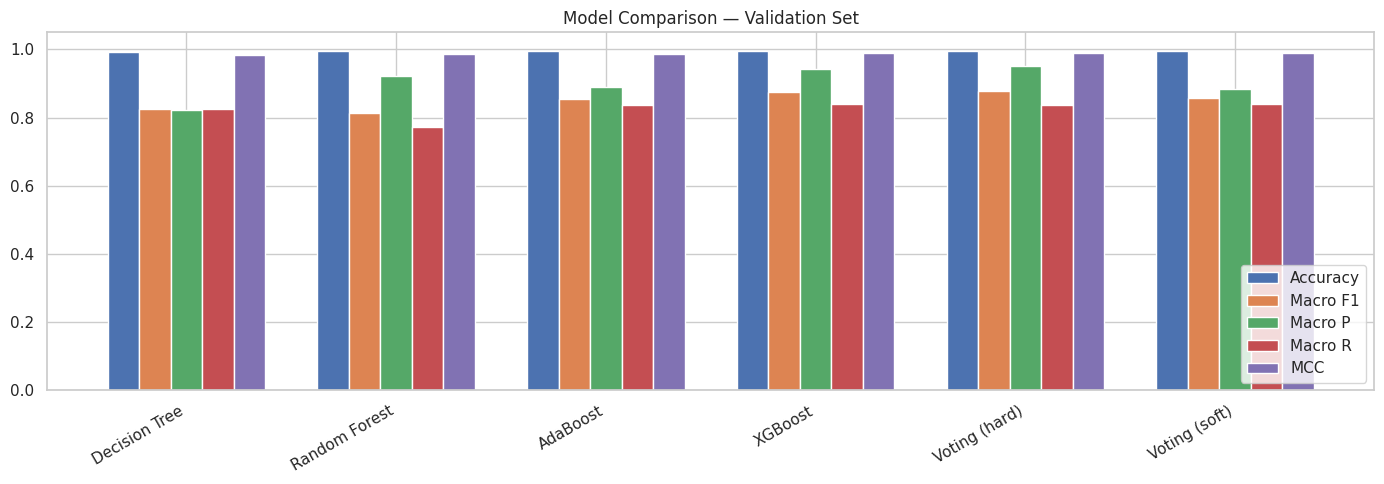

In [7]:
df_val = pd.DataFrame(results_val).set_index('Model')
best_model_name = df_val['Macro F1'].idxmax()

print('=== Validation Results ===')
print(df_val.to_string())
print(f'\nBest model (val Macro F1): {best_model_name} — {df_val.loc[best_model_name,"Macro F1"]:.4f}')
print()

metrics = ['Accuracy','Macro F1','Macro P','Macro R','MCC']
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(df_val))
width = 0.15
for j, m in enumerate(metrics):
    ax.bar(x + j*width, df_val[m], width, label=m)
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_val.index, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Validation Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## §12 Final Evaluation on Test Set

The test set is used here for the first and only time — it was not seen
during training or Optuna tuning. Comparing val and test results detects
overfitting to the validation set. The confusion matrix for the best model
exposes which class pairs are mutually confused; expected confusions are
Web-based ↔ Benign and BruteForce ↔ Recon due to overlapping traffic patterns
documented in the original paper (Neto et al., 2023).

In [ ]:
# Recovery — refit models skipped by the checkpoint
import time as _t

if 'dt' not in dir():
      print('Refitting Decision Tree...', end=' ', flush=True)
      dt = DecisionTreeClassifier(random_state=SEED)
      dt.fit(X_train_res, y_train_res)
      print('done')

if 'rf' not in dir():
      print('Refitting Random Forest (~5 min)...')
      _t0 = _t.time()
      rf = RandomForestClassifier(**rf_best_params, n_jobs=-1, random_state=SEED)
      rf.fit(X_train_res, y_train_res)
      print(f'done in {(_t.time()-_t0)/60:.1f} min')

Refitting Decision Tree... done
Refitting Random Forest (~5 min)...
done in 1.0 min
Refitting AdaBoost (100 estimators)...


In [8]:
# Evaluate every model that was actually trained this session.
# Stacking is included only if stack is not None (i.e., §10 was executed).
models_to_eval = [
    ('Decision Tree',     dt),
    ('Random Forest',     rf),
    ('AdaBoost',          ada),
    ('Gradient Boosting', gb),
    ('XGBoost',           xgb_model),
    ('Voting (hard)',     vote_hard),
    ('Voting (soft)',     vote_soft),
]
if stack is not None:
    models_to_eval.append(('Stacking', stack))

for name, model in models_to_eval:
    print(f'{name}:')
    evaluate_model(name, model, X_test, y_test, results_test)
    print()

df_test = pd.DataFrame(results_test).set_index('Model')
best_test_name = df_test['Macro F1'].idxmax()

print('=== Test Results ===')
print(df_test.sort_values('Macro F1', ascending=False).to_string())
print(f'\nBest model (test Macro F1): {best_test_name}')
print()

best_model_obj = dict(models_to_eval)[best_test_name]
y_pred_best = best_model_obj.predict(X_test)

print(f'=== {best_test_name} — Classification Report ===')
print(classification_report(y_test, y_pred_best,
      target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=CLASS_NAMES,
    normalize='true', cmap='Blues',
    xticks_rotation=45, ax=ax
)
ax.set_title(f'Confusion Matrix — {best_test_name} (normalised, test set)')
plt.tight_layout()
plt.show()

NameError: name 'dt' is not defined

## §13 Export Results for Notebook 04

Metrics and hyperparameters are saved to CSV/JSON so that notebook 04
loads them independently. No model objects are serialised — notebook 04
performs only analysis and visualisation, requiring no sklearn/xgboost
at runtime.

In [ ]:
df_val.reset_index().to_csv(PROCESSED_DIR + 'results_val.csv', index=False)
df_test.reset_index().to_csv(PROCESSED_DIR + 'results_test.csv', index=False)

best_hparams = {
    'RandomForest':     rf_best_params,
    'AdaBoost':         {**ada_best_params, 'base_max_depth': ada_base_depth},
    'GradientBoosting': gb_best_params,
    'XGBoost':          xgb_best_params,
}
with open(PROCESSED_DIR + 'best_hparams.json', 'w') as f:
    json.dump(best_hparams, f, indent=2)

with open(PROCESSED_DIR + 'best_model_name.json', 'w') as f:
    json.dump({'val_best': best_model_name, 'test_best': best_test_name}, f, indent=2)

print('Exported:')
for fname in ['results_val.csv','results_test.csv','best_hparams.json','best_model_name.json']:
    size = os.path.getsize(PROCESSED_DIR + fname)
    print(f'  {fname:<35} {size:,} bytes')